In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather, InitialConditions

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_rakican import rakican_soil_layers, rakican_curve_number, \
    rakican_readily_evaporable_water, rakican_maize_params, rakican_optimal_management, rakican_groundwater, \
    rakican_soil_layers_old, rakican_soil_layers_podrobno, rakican_initial_cond
from aquacrop_slovenia.diagnostics import nse, kge, mkge

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing2"
LOCATION = "rakican"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

There is no yield observations for 1998 and 2023, so those years are excluded. Year 2017 is excluded due to missing ET data.

In [4]:
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10), # TODO
        "planting_date": date(year, 4, 20), # TODO
        "is_seeding_year": True,
    }
for year in range(1993, 2024) if year not in [1998,2023,2017]]

In [5]:
rakican_temperatures, rakican_eto, rakican_rain = load_station_weather(355) # Rakičan uses ARSO meteo station 355 data

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
rakican_weather = Weather(
    location=LOCATION,
    temperatures=rakican_temperatures,
    eto_values=rakican_eto,
    rainfall_values=rakican_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
rakican_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=rakican_maize_params
)

In [9]:
rakican_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=rakican_soil_layers,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water
)

In [10]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=rakican_maize,
    soil=rakican_soil,
    management=rakican_optimal_management,
    initial_conditions=rakican_initial_cond,
    #ground_water=rakican_groundwater,
    climate=rakican_weather,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [11]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing2
Running AquaCrop simulation with project file: E:\aquacrop\testing2\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing2\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [12]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,413.9,754.2,1726.1,355.97,0.0,399.8,...,46.5,13.648,16.443,3.19,0.0,0.0,10,10,1993,PROJECT.PRM
1,2,1,1,1994,789.6,737.2,1831.9,357.58,0.0,744.4,...,46.1,13.328,16.058,2.84,0.0,0.0,10,10,1994,PROJECT.PRM
2,3,1,1,1995,820.1,695.1,1621.6,359.53,0.0,763.9,...,8.9,2.641,3.182,0.59,0.0,0.0,10,10,1995,PROJECT.PRM
3,4,1,1,1996,885.7,646.3,1515.4,361.26,0.0,815.2,...,7.6,2.209,2.662,0.55,0.0,0.0,10,10,1996,PROJECT.PRM
4,5,1,1,1997,541.3,710.3,1609.5,362.43,0.0,528.0,...,12.6,3.867,4.659,0.93,0.0,0.0,10,10,1997,PROJECT.PRM
5,6,1,1,1999,614.4,673.6,1810.3,366.96,0.0,598.5,...,46.3,14.659,17.662,3.20,0.0,0.0,10,10,1999,PROJECT.PRM
6,7,1,1,2000,467.3,778.2,1893.5,368.25,0.0,460.1,...,22.9,2.470,2.976,0.90,0.0,0.0,10,10,2000,PROJECT.PRM
7,8,1,1,2001,578.3,726.8,1776.2,369.65,0.0,556.1,...,46.0,11.996,14.453,2.86,0.0,0.0,10,10,2001,PROJECT.PRM
8,9,1,1,2002,573.1,732.0,1799.7,371.87,0.0,564.2,...,46.3,14.002,16.869,2.97,0.0,0.0,10,10,2002,PROJECT.PRM
9,10,1,1,2003,417.1,808.8,1978.6,374.22,0.0,409.1,...,36.7,6.112,7.364,1.84,0.0,0.0,10,10,2003,PROJECT.PRM


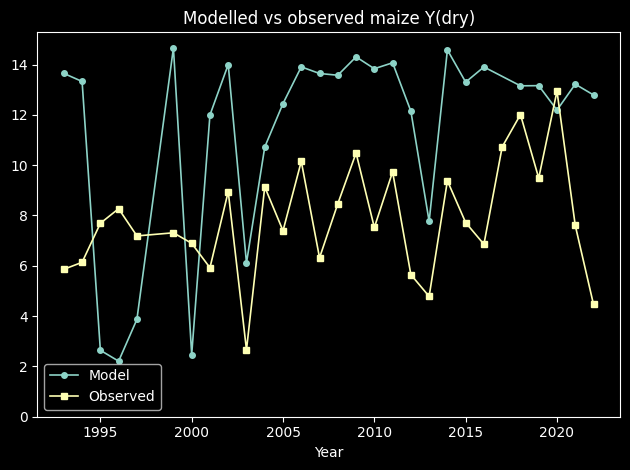

In [13]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

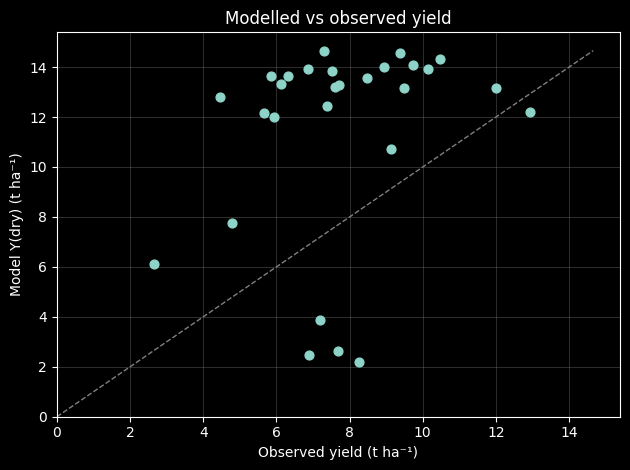

In [14]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [15]:
print(root_mean_squared_error(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))
print(r2_score(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))
print(nse(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))
print(kge(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))
print(mkge(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))

2.6793159808055487
0.08018992214669896
-4.916573449194357
-0.17459843935093233
0.10508396849441826


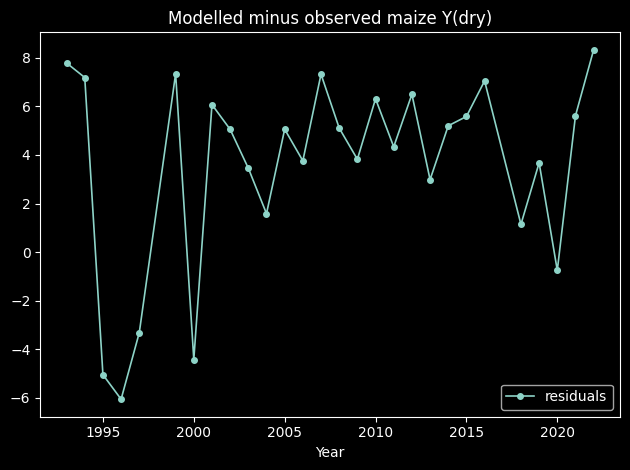

In [16]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

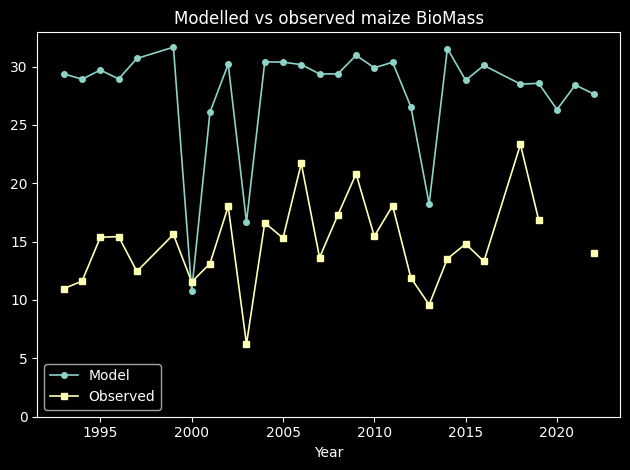

In [17]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass")

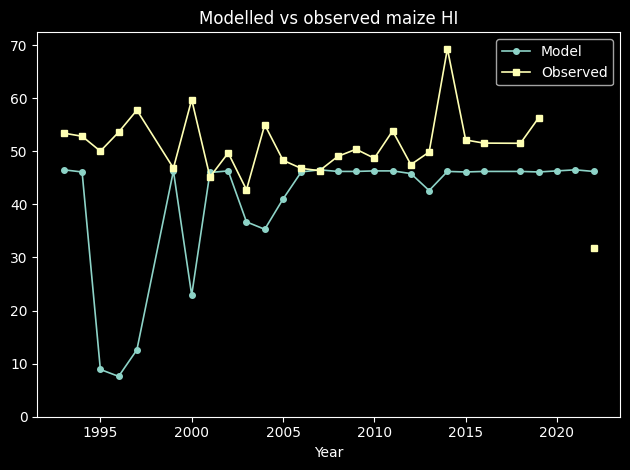

In [18]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI")

In [19]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.00),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,378.3,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,377.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,376.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,378.0,1.4,0.0,0.0,1.4,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,378.6,0.6,0.0,0.0,0.6,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,1993,170,4,283.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
279,7,10,1993,171,4,283.0,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
280,8,10,1993,172,4,282.3,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
281,9,10,1993,173,4,282.2,1.0,0.0,0.0,1.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

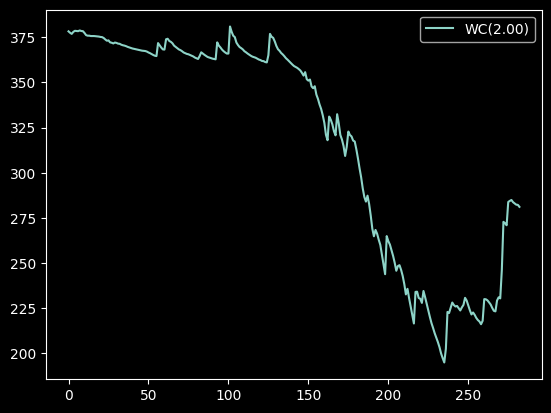

In [20]:
results["day"].plot(y="WC(2.00)")

<Axes: >

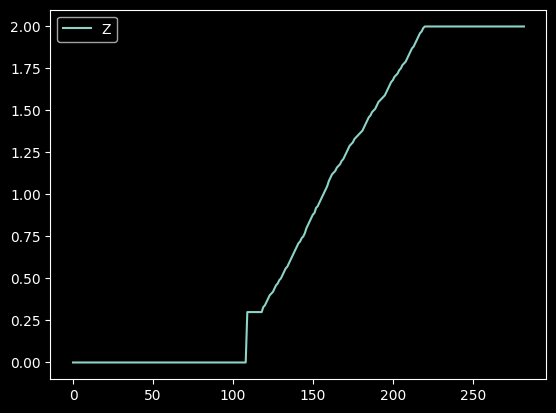

In [21]:
results["day"].plot(y="Z")

<Axes: >

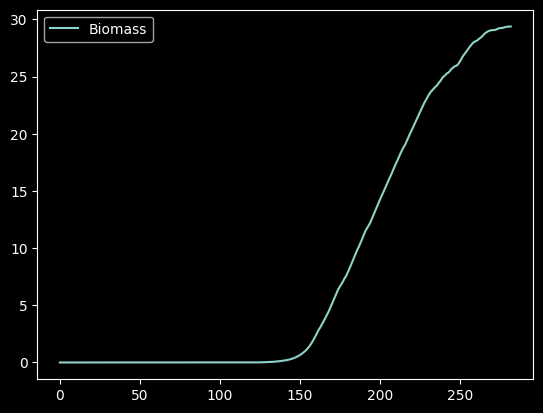

In [22]:
results["day"].plot(y="Biomass")

<Axes: >

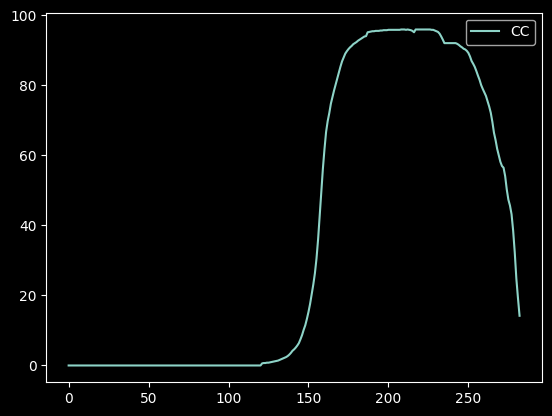

In [23]:
results["day"].plot(y="CC")

<Axes: >

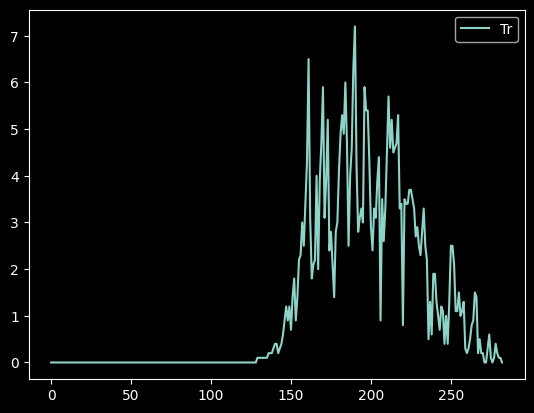

In [24]:
results["day"].plot(y="Tr")

<Axes: >

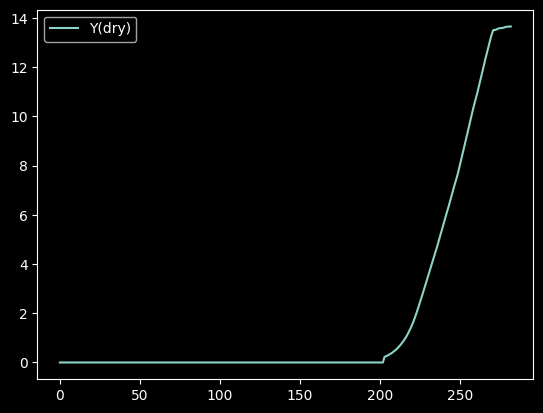

In [25]:
results["day"].plot(y="Y(dry)")